## 1. RQ1 and RQ2 (first part)

In [ ]:
import os
import sys
from pathlib import Path
current_dir = os.getcwd()
root_dir = Path(current_dir).resolve().parent
print(f"Current working directory: {root_dir}")
sys.path.append(str(root_dir))
exp_dir = "../experiments/"
exp_sample = "../experiments/sst2_ablate_distilbert_base_uncased_attn_lm_0.0_20260213_040643"

task = "sst2"

## load result table and filter task

In [ ]:
import pandas as pd
df_master = pd.read_csv(Path(exp_dir) / "master_results.csv")

In [16]:
print("number of inject lm",df_master[(df_master['operation'] == "inject") & (df_master['strategy'] == "lm")]["total_proposals"].sum())
print("number of inject random",df_master[(df_master['operation'] == "inject") & (df_master['strategy'] == "random")]["total_proposals"].sum())
print("number of inject prefix",df_master[(df_master['operation'] == "inject") & (df_master['strategy'] == "prefix")]["total_proposals"].sum())
print("number of ablate lm",df_master[(df_master['operation'] == "ablate") & (df_master['strategy'] == "lm")]["total_proposals"].sum())
print("number of ablate random",df_master[(df_master['operation'] == "ablate") & (df_master['strategy'] == "random")]["total_proposals"].sum())

number of inject lm 26503
number of inject random 26503
number of inject prefix 26503
number of ablate lm 36201
number of ablate random 36201


In [ ]:
df_time = df_master[(df_master['explainer'] == "occlusion")].copy()
df_time['duratiom_per_attack'] = df_time['duration_seconds']/df_time['total_proposals']

In [ ]:
df_xai = df_master[(df_master['operation'] == "ablate") & (df_master['strategy'] == "random") & (df_master['task'] == "sst2")]

In [ ]:
df_plot = df_xai.rename(columns={2: 'model', 4: 'xai', 15: 'max_neg_flip_rate', 18: 'max_pos_flip_rate'})

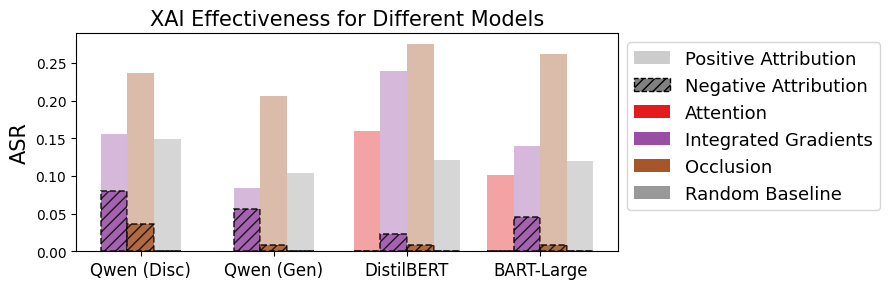

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
plt.style.use('default')
# load data
df = df_xai.copy()
column_names = {'model': 'model_orig', 'explainer': 'xai_orig', 15: 'max_neg_flip_rate', 18: 'max_pos_flip_rate'}
df_plot = df.rename(columns=column_names)[['model_orig', 'xai_orig', 'max_neg_flip_rate', 'max_pos_flip_rate']]

# ==========================================
# 2. mapping
# ==========================================
model_mapping = {
    'distilbert-base-uncased': 'DistilBERT',
    'facebook/bart-large': 'BART-Large',
    'Qwen/Qwen2.5-0.5B': 'Qwen (Disc)',
    'Qwen/Qwen2.5-0.5B_gen': 'Qwen (Gen)'
}

# XAI name mapping
xai_mapping = {
    'ig': 'Integrated Gradients',
    'occlusion': 'Occlusion',
    'attn': 'Attention',
    'random': 'Random Baseline'
}

# X axis order
model_order = [ 'Qwen (Disc)', 'Qwen (Gen)', 'DistilBERT', 'BART-Large']

# ==========================================
# 3. data processing
# ==========================================
df_plot['model'] = df_plot['model_orig'].astype(str).map(model_mapping).fillna(df_plot['model_orig'])
df_plot['xai'] = df_plot['xai_orig'].astype(str).map(xai_mapping).fillna(df_plot['xai_orig'])

# aggregate by model and xai, compute mean of numeric columns
numeric_cols = ['max_pos_flip_rate', 'max_neg_flip_rate']
df_final = df_plot.groupby(['model', 'xai'], observed=True)[numeric_cols].mean().reset_index()

# ==========================================
# 4. plotting
# ==========================================
fig, ax = plt.subplots(figsize=(9, 3))

#define colors for each XAI method
all_unique_xais = sorted(df_final['xai'].unique())
color_palette = plt.cm.Set1(np.linspace(0, 1, len(all_unique_xais)))
xai_colors = {xai: color_palette[i] for i, xai in enumerate(all_unique_xais)}

bar_width = 0.2  
x_indices = np.arange(len(model_order)) 

for m_idx, model in enumerate(model_order):
    model_data = df_final[df_final['model'] == model]
    present_xais = sorted(model_data['xai'].tolist()) 
    num_bars = len(present_xais)

    offsets = (np.arange(num_bars) - (num_bars - 1) / 2) * bar_width

    for i, xai in enumerate(present_xais):
        row = model_data[model_data['xai'] == xai]
        pos_val = row['max_pos_flip_rate'].values[0]
        neg_val = row['max_neg_flip_rate'].values[0]

        bar_x = x_indices[m_idx] + offsets[i]

        ax.bar(bar_x, pos_val, width=bar_width, color=xai_colors[xai], alpha=0.4)

        ax.bar(bar_x, neg_val, width=bar_width, color=xai_colors[xai],
               edgecolor='black', linestyle='--', linewidth=1.2, hatch='///', alpha=0.8)

# 5. legend
legend_elements = [
    Patch(facecolor='gray', alpha=0.4, label='Positive Attribution'),
    Patch(facecolor='gray', edgecolor='black', linestyle='--', hatch='///', label='Negative Attribution')
]

for xai in all_unique_xais:
    legend_elements.append(Patch(facecolor=xai_colors[xai], label=xai))

ax.set_xticks(x_indices)
ax.set_xticklabels(model_order,
                   size=12,
                   )
ax.set_ylabel('ASR', size=15)
ax.set_title('XAI Effectiveness for Different Models', size=15)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=13)
ax.grid(False)
plt.tight_layout()
plt.savefig('final_optimized_plot.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# add ppl log diff to the files

import json
from src.mutator import PPLCalculatorCorrect, PPLCalculator2, NLIChecker
from pathlib import Path
import os

from tqdm import tqdm

def compute_ppl_log_diff(task):
    exp_path = Path(exp_dir)
    nli_checker = NLIChecker(model_name="cross-encoder/nli-deberta-v3-small")
    log_ppl = PPLCalculatorCorrect()
    # Iterate through each experiment folder
    for subdir in exp_path.iterdir():
        if not subdir.is_dir():
            continue
        if task not in subdir.name:
            continue


        config_file = subdir / "config.json"
        attempts_file = subdir / "probes" / "attempts.jsonl"
        attempt_file_fixed = subdir / "probes" / "attempts_fixed.jsonl"
        failures_file = subdir / "probes" / "failures.jsonl"
        failures_file_fixed = subdir / "probes" / "failures_fixed.jsonl"
        # Check if necessary files exist

        if not config_file.exists() or not attempts_file.exists() or not failures_file.exists():
            print("Warning: config file or attempts/failures file not found. Skipping PPL recomputation.")
            continue
        elif failures_file_fixed.exists():
            failures_file = failures_file_fixed
            attempts_file = attempt_file_fixed

        print(f"Starting PPL diff recomputation for {failures_file}")

        # Instantiate PPLCalculatorCorrect once to load the model efficiently

        #ppl2 = PPLCalculator2()
        updated_failure_records = []
        original_failures_count = 0

        # Read the original failures.jsonl file
        with open(failures_file, 'r', encoding='utf-8') as f_in:
            for line in tqdm(f_in, desc="Reading and calculating PPL diffs"):
                original_failures_count += 1
                try:
                    record = json.loads(line.strip())
                    original_text_a = record.get("original", {}).get("text_a")
                    original_text_b = record.get("original", {}).get("text_b")
                    edited_text_a = record.get("edited", {}).get("text_a")
                    edited_text_b = record.get("edited", {}).get("text_b")
                    combined_text = f"{original_text_a} {original_text_b}" if original_text_b is not None else original_text_a
                    combined_text_edit = f"{edited_text_a} {edited_text_b}" if edited_text_b is not None else edited_text_a


                    if original_text_a is not None and edited_text_a is not None:
                        # compute_diff returns a list of floats. We expect a single float for each record.
                        new_ppl_diff_list = log_ppl.compute_diff([combined_text], [combined_text_edit])
                        nli_info = nli_checker.check_bidirectional_entailment(combined_text, combined_text_edit, threshold=0.0)

                        #new_ppl_diff_list2 = ppl2.compute_diff([original_text_a], [edited_text_a])
                        if new_ppl_diff_list:
                            record["log_ppl_diff_fixed"] = new_ppl_diff_list[0]
                            record["nli_scores_fixed"] = {"forward": nli_info["forward_score"], "backward": nli_info["backward_score"]}
                            #record["log_ppl_diff2"] = new_ppl_diff_list2[0]
                        else:
                            print(
                                f"Warning: compute_diff returned empty for record {original_failures_count}. Keeping original ppl_diff or defaulting.")
                    else:
                        print(
                            f"Warning: Missing 'original.text_a' or 'edited.text_a' in record {original_failures_count}. Skipping PPL diff recomputation for this record.")

                    updated_failure_records.append(json.dumps(record, ensure_ascii=False))

                except json.JSONDecodeError as e:
                    print(f"Error decoding JSON in line {original_failures_count}: {e}. Skipping this line.")
                except Exception as e:
                    print(f"An unexpected error occurred for line {original_failures_count}: {e}. Skipping this line.")

        # Write the updated records to a temporary file
        temp_failures_file = failures_file.parent / (failures_file.name + ".tmp")
        with open(temp_failures_file, 'w', encoding='utf-8') as f_out:
            for record_str in tqdm(updated_failure_records, desc="Writing updated failures file"):
                f_out.write(record_str + '\n')

        # Atomically replace the original file with the updated one
        os.replace(temp_failures_file, failures_file)
        print(f"Finished recomputing PPL diffs for {original_failures_count} records in {failures_file}.")
        print(f"Original file replaced with updated content at {failures_file}")

# compute_ppl_log_diff(task)

In [1]:
# ... existing code ...
import json
import pandas as pd
from pathlib import Path

all_records = []
all_failures_records = []
exp_dir_backup = "../experiments_backup"
exp_path_backup = Path(exp_dir_backup)

# Iterate through each experiment folder
for subdir in exp_path_backup.iterdir():
    if not subdir.is_dir():
        continue
    #if task not in subdir.name:
    #    continue

    config_file = subdir / "config.json"
    attempts_file = subdir / "probes" / "attempts.jsonl"
    failures_file = subdir / "probes" / "failures.jsonl"

    attempts_file = subdir / "probes" / "attempts.jsonl"
    attempt_file_fixed = subdir / "probes" / "attempts_fixed.jsonl"
    failures_file = subdir / "probes" / "failures.jsonl"
    failures_file_fixed = subdir / "probes" / "failures_fixed.jsonl"
    # Check if necessary files exist

    if not config_file.exists() or not attempts_file.exists() or not failures_file.exists():
        print("Warning: config file or attempts/failures file not found. Skipping PPL recomputation.")
        continue
    elif failures_file_fixed.exists():
        failures_file = failures_file_fixed
        attempts_file = attempt_file_fixed


    # Load configuration
    with open(config_file, 'r') as f:
        config = json.load(f)

    # Extract metadata
    meta = {
        "model": config.get("model"),
        "explainer": config.get("explainer"),
        "strategy": config.get("strategy"),
        "operation": config.get("operation")
    }

    # Load attempts and filter for flipped cases
    with open(attempts_file, 'r') as f:
        for line in f:
            data = json.loads(line)
            if data.get("flipped"):
                record = meta.copy()
                record.update({
                    "item_id": data.get("item_id"),
                    "word": data.get("word"),
                    "ppl_diff": data.get("ppl_diff"),
                    "flipped":data.get("flipped")
                    #"nli_forward": data.get("nli_scores", {}).get("forward"),
                    #"nli_backward": data.get("nli_scores", {}).get("backward")
                })
                all_records.append(record)

    # Load failures and extract original text info
    with open(failures_file, 'r') as f:
        for line in f:
            data = json.loads(line)
            original_data = data.get("original", {})  # Access the 'original' sub-dictionary
            edit_data = data.get("edited", {})  # Access the 'original' sub-dictionary
            record_failure = meta.copy()
            record_failure.update({
                "item_id": original_data.get("id"),
                "text_a": original_data.get("text_a"),
                "text_b": original_data.get("text_b"),
                "true_label": original_data.get("true_label"),
                "edit_text_a": edit_data.get("text_a"),
                "edit_text_b": edit_data.get("text_b"),
                "ppl_diff": data.get("ppl_diff"),
                "log_ppl_diff": data.get("log_ppl_diff_fixed"),
                "nli_forward": data.get("nli_scores_fixed", {}).get("forward"),
                "nli_backward": data.get("nli_scores_fixed", {}).get("backward")
            })
            all_failures_records.append(record_failure)

df_flipped = pd.DataFrame(all_records)
df_failures = pd.DataFrame(all_failures_records)  # Create a new DataFrame for failures data
df_flipped = pd.merge(df_failures.drop_duplicates(), df_flipped.drop_duplicates(), on=['item_id', "ppl_diff","model","explainer","strategy", "operation"], how='inner')

In [2]:
df_flipped

,model,explainer,strategy,operation,item_id,text_a,text_b,true_label,edit_text_a,edit_text_b,ppl_diff,log_ppl_diff,nli_forward,nli_backward,word,flipped
0,Qwen/Qwen2.5-0.5B_gen,ig,random,inject,news_66853,Samsung Introduces First 5-Megapixel Camera Phone,Samsung is turning up the heat in the mobile c...,3,Samsung Introduces First 5-Megapixel Camera Ph...,Samsung is turning up the heat in the mobile c...,3.749710,0.089784,0.274081,0.975128,No,True
1,Qwen/Qwen2.5-0.5B_gen,ig,random,inject,news_89758,Fellow users are the best support,A telephone call to the technical support hotl...,3,Fellow users are the Tags best support,A telephone call to the technical support hotl...,30.631199,0.524828,0.114533,0.965761,Tags,True
2,Qwen/Qwen2.5-0.5B_gen,ig,random,inject,news_39393,Spain Edge Closer to Davis Cup Final,LONDON (Reuters) - Spain stepped closer to th...,1,Spain &lt;i&gt Edge Closer to Davis Cup Final,LONDON (Reuters) - Spain stepped closer to th...,54.705643,0.370752,0.315838,0.907712,&lt;i&gt,True
3,Qwen/Qwen2.5-0.5B_gen,ig,random,inject,news_84590,To: National Desk and Environment Reporter,"WASHINGTON, Nov. 8 /US Newswire/ -- The scient...",3,To: National line Desk and Environment Reporter,"WASHINGTON, Nov. 8 /US Newswire/ -- The scient...",15.789536,0.241654,0.925596,0.926502,line,True
4,Qwen/Qwen2.5-0.5B_gen,ig,random,inject,news_35287,Coles Myer rings up record profit,Australia #39;s biggest retailer Coles Myer ha...,2,Coles Myer rings up sanctions.ĊCategory record...,Australia #39;s biggest retailer Coles Myer ha...,88.319946,0.523991,0.049637,0.987291,sanctions.ĊCategory,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27797,facebook/bart-large,attn,prefix,inject,news_50782,Britain Blocks Drug Firm From Supplying Flu Va...,The company that makes half the flu vaccine us...,0,said Britain Blocks Drug Firm From Supplying F...,The company that makes half the flu vaccine us...,34.500816,0.305221,0.978337,0.980971,said,True
27798,facebook/bart-large,attn,prefix,inject,news_99935,Anger Management May Not Help at All,The brawl that erupted last week at a basketba...,1,"""paternalistic Anger Management May Not Help a...",The brawl that erupted last week at a basketba...,19.993874,0.158267,0.015195,0.959607,"""paternalistic",True
27799,facebook/bart-large,attn,prefix,inject,news_86471,Dolphins GM may not have total job security,Replacing coach Dave Wannstedt isn #39;t the o...,1,Lufthansa Dolphins GM may not have total job s...,Replacing coach Dave Wannstedt isn #39;t the o...,-3.755760,-0.131021,0.004479,0.996486,Lufthansa,True
27800,facebook/bart-large,attn,prefix,inject,news_116118,"Nortel reports loss in Q3, sees pickup in Q4",Amid continuing problems with the release of i...,3,"just Nortel reports loss in Q3, sees pickup in Q4",Amid continuing problems with the release of i...,7.066521,-0.058243,0.972318,0.991597,just,True


In [ ]:
df_flipped['strategy_label'] = df_flipped['strategy']

# write strategy_label
df_flipped.loc[(df_flipped['operation'] == 'ablate') & (df_flipped['strategy'] == 'lm'), 'strategy_label'] = 'LLM (ablate)'
df_flipped.loc[(df_flipped['operation'] == 'inject') & (df_flipped['strategy'] == 'lm'), 'strategy_label'] = 'LLM (inject)'
df_flipped.loc[(df_flipped['operation'] == 'ablate') & (df_flipped['strategy'] == 'random'), 'strategy_label'] = 'in-situ (ablate)'
df_flipped.loc[(df_flipped['operation'] == 'inject') & (df_flipped['strategy'] == 'random'), 'strategy_label'] = 'random (inject)'
df_flipped.loc[(df_flipped['operation'] == 'inject') & (df_flipped['strategy'] == 'prefix'), 'strategy_label'] = 'prefix (inject)'


In [ ]:
ppl_threshold = 0.3#1
nli_threshold = 0.08#0.08
df_flipped_filter = df_flipped[(df_flipped['log_ppl_diff'] <= ppl_threshold) & (df_flipped['nli_forward'] >= nli_threshold) & (df_flipped['nli_backward'] >= nli_threshold)& (df_flipped['explainer'] == 'occlusion')].copy()
df_flipped_filter['task'] = df_flipped_filter['item_id'].apply(lambda x: x.split('_')[0])

In [40]:
counts_grouped = df_flipped_filter.groupby(['model', 'explainer', 'strategy', 'operation', 'task']).size().reset_index(name='count')

rq2_table = counts_grouped.pivot_table(
    index=['task','operation', 'strategy'],
    columns=['model','explainer'],
    values=['count', ]
)
rq2_table

count                               \
model                     Qwen/Qwen2.5-0.5B        Qwen/Qwen2.5-0.5B_gen   
explainer                         occlusion random             occlusion   
task   operation strategy                                                  
github ablate    lm                   285.0  144.0                 230.0   
                 random                90.0   44.0                 128.0   
       inject    lm                   226.0  233.0                 188.0   
                 prefix                64.0   59.0                 232.0   
                 random                44.0   34.0                 109.0   
news   ablate    lm                    82.0   54.0                 586.0   
                 random               121.0   65.0                  74.0   
       inject    lm                    50.0   52.0                 341.0   
                 prefix                20.0   20.0                 181.0   
                 random                62.0   57.0                  86.0   
sst2   ablate    lm                   162.0  121.0                 135.0   
                 random               452.0  279.0                 400.0   
       inject    lm                   180.0  158.0                 128.0   
                 prefix               110.0  109.0                 147.0   
                 random               203.0  181.0                  96.0   

                                                                 \
model                            distilbert-base-uncased          
explainer                 random               occlusion random   
task   operation strategy                                         
github ablate    lm        101.0                   371.0  187.0   
                 random     47.0                   135.0   31.0   
       inject    lm        195.0                   275.0  227.0   
                 prefix    223.0                   103.0   98.0   
                 random    132.0                    43.0   41.0   
news   ablate    lm        335.0                    56.0   18.0   
                 random     52.0                    85.0   14.0   
       inject    lm        298.0                    28.0   35.0   
                 prefix    187.0                    47.0   25.0   
                 random     97.0                    36.0   22.0   
sst2   ablate    lm         55.0                   212.0   89.0   
                 random    199.0                   525.0  228.0   
       inject    lm         85.0                   164.0  119.0   
                 prefix    121.0                   155.0   95.0   
                 random     92.0                   138.0   90.0   

                                                      
model                     facebook/bart-large         
explainer                           occlusion random  
task   operation strategy                             
github ablate    lm                     349.0  136.0  
                 random                 126.0   30.0  
       inject    lm                     262.0  236.0  
                 prefix                  81.0   64.0  
                 random                  44.0   41.0  
news   ablate    lm                      32.0    7.0  
                 random                  52.0   11.0  
       inject    lm                      23.0   32.0  
                 prefix                  26.0   43.0  
                 random                  14.0   27.0  
sst2   ablate    lm                     154.0   85.0  
                 random                 497.0  227.0  
       inject    lm                     128.0  120.0  
                 prefix                 115.0  123.0  
                 random                 112.0  111.0

In [41]:
# ... existing code ...
counts_total_attempt = df_master[df_master['model']!='Qwen/Qwen2.5-0.5B_gen_'].groupby(['model', 'explainer', 'strategy', 'operation', 'task'])[
    'total_proposals'].sum()


# 1. Convert counts_total_attempt Series to DataFrame and reset index
counts_total_attempt_df = counts_total_attempt.reset_index()

# 3. Filter for the 'occlusion' explainer, as `rq2_table` is derived from `df_flipped_filter`,
# which specifically filters for `explainer == 'occlusion'`. This ensures a correct apples-to-apples comparison.
filtered_total_attempt_df = counts_total_attempt_df[(counts_total_attempt_df['explainer'] == 'occlusion') | (counts_total_attempt_df['explainer'] == 'random')]

# 4. Create a pivot table for 'total_proposals' with the same index and column structure as `rq2_table`.
# This is crucial for proper alignment during the division operation.
total_proposals_pivot = filtered_total_attempt_df.pivot_table(
    index=['task', 'operation', 'strategy'],
    columns=['model','explainer'],
    values=['total_proposals']
)

# Rename the first level of columns of `total_proposals_pivot` to 'count'.
# This makes the column MultiIndex `('count', 'model_name')`, matching `rq2_table`'s structure.
# Pandas will then correctly align and divide values for each 'model'.
total_proposals_pivot.columns = total_proposals_pivot.columns.set_levels(['count'], level=0)

# 5. Calculate the rate by dividing `rq2_table` (which contains 'count' of effective failures)
# by `total_proposals_pivot` (which contains 'total_proposals' for the corresponding experiments).
# Pandas' advanced indexing will automatically align rows and columns based on their MultiIndex levels.
rq2_rate_table = rq2_table / total_proposals_pivot

# Display the newly calculated rate table.
rq2_rate_table


count                                  \
model                     Qwen/Qwen2.5-0.5B           Qwen/Qwen2.5-0.5B_gen   
explainer                         occlusion    random             occlusion   
task   operation strategy                                                     
github ablate    lm                0.086996  0.083382              0.083092   
                 random            0.027795  0.025478              0.046243   
       inject    lm                0.130109  0.134139              0.124503   
                 prefix            0.036909  0.033967              0.153642   
                 random            0.025331  0.019574              0.072185   
news   ablate    lm                0.025169  0.028511              0.187340   
                 random            0.037139  0.034319              0.023657   
       inject    lm                0.026399  0.027455              0.186339   
                 prefix            0.010560  0.010560              0.098907   
                 random            0.032735  0.030095              0.046995   
sst2   ablate    lm                0.055177  0.064327              0.042980   
                 random            0.153951  0.148325              0.127348   
       inject    lm                0.095694  0.083998              0.066806   
                 prefix            0.058480  0.057948              0.076722   
                 random            0.107921  0.096225              0.050104   

                                                                       \
model                               distilbert-base-uncased             
explainer                    random               occlusion    random   
task   operation strategy                                               
github ablate    lm        0.067288                0.110779  0.108847   
                 random    0.031312                0.040311  0.018044   
       inject    lm        0.129139                0.160070  0.131977   
                 prefix    0.147682                0.059953  0.056977   
                 random    0.087417                0.025029  0.023837   
news   ablate    lm        0.183060                0.015625  0.009815   
                 random    0.028415                0.023717  0.007634   
       inject    lm        0.162842                0.015267  0.019084   
                 prefix    0.102186                0.025627  0.013631   
                 random    0.053005                0.019629  0.011996   
sst2   ablate    lm        0.028706                0.070950  0.047215   
                 random    0.103862                0.175703  0.120955   
       inject    lm        0.044363                0.087003  0.063130   
                 prefix    0.063152                0.082228  0.050398   
                 random    0.048017                0.073210  0.047745   

                                                         
model                     facebook/bart-large            
explainer                           occlusion    random  
task   operation strategy                                
github ablate    lm                  0.104868  0.078932  
                 random              0.037861  0.017411  
       inject    lm                  0.151096  0.136101  
                 prefix              0.046713  0.036909  
                 random              0.025375  0.023645  
news   ablate    lm                  0.008490  0.003667  
                 random              0.013797  0.005762  
       inject    lm                  0.012048  0.016763  
                 prefix              0.013620  0.022525  
                 random              0.007334  0.014144  
sst2   ablate    lm                  0.056722  0.044902  
                 random              0.183057  0.119915  
       inject    lm                  0.067618  0.063391  
                 prefix              0.060750  0.064976  
                 random              0.059165  0.058637

In [42]:
(rq2_rate_table*100).to_latex(float_format="%.2f")

'\\begin{tabular}{lllrrrrrrrr}\n\\toprule\n &  &  & \\multicolumn{8}{r}{count} \\\\\n &  & model & \\multicolumn{2}{r}{Qwen/Qwen2.5-0.5B} & \\multicolumn{2}{r}{Qwen/Qwen2.5-0.5B_gen} & \\multicolumn{2}{r}{distilbert-base-uncased} & \\multicolumn{2}{r}{facebook/bart-large} \\\\\n &  & explainer & occlusion & random & occlusion & random & occlusion & random & occlusion & random \\\\\ntask & operation & strategy &  &  &  &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{5}{*}{github} & \\multirow[t]{2}{*}{ablate} & lm & 8.70 & 8.34 & 8.31 & 6.73 & 11.08 & 10.88 & 10.49 & 7.89 \\\\\n &  & random & 2.78 & 2.55 & 4.62 & 3.13 & 4.03 & 1.80 & 3.79 & 1.74 \\\\\n\\cline{2-11}\n & \\multirow[t]{3}{*}{inject} & lm & 13.01 & 13.41 & 12.45 & 12.91 & 16.01 & 13.20 & 15.11 & 13.61 \\\\\n &  & prefix & 3.69 & 3.40 & 15.36 & 14.77 & 6.00 & 5.70 & 4.67 & 3.69 \\\\\n &  & random & 2.53 & 1.96 & 7.22 & 8.74 & 2.50 & 2.38 & 2.54 & 2.36 \\\\\n\\cline{1-11} \\cline{2-11}\n\\multirow[t]{5}{*}{news} & \\multirow[t]

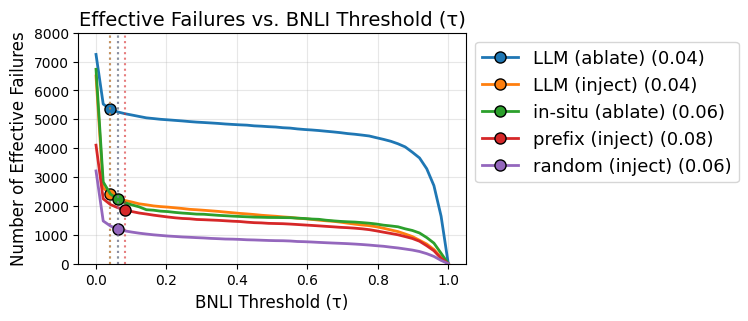

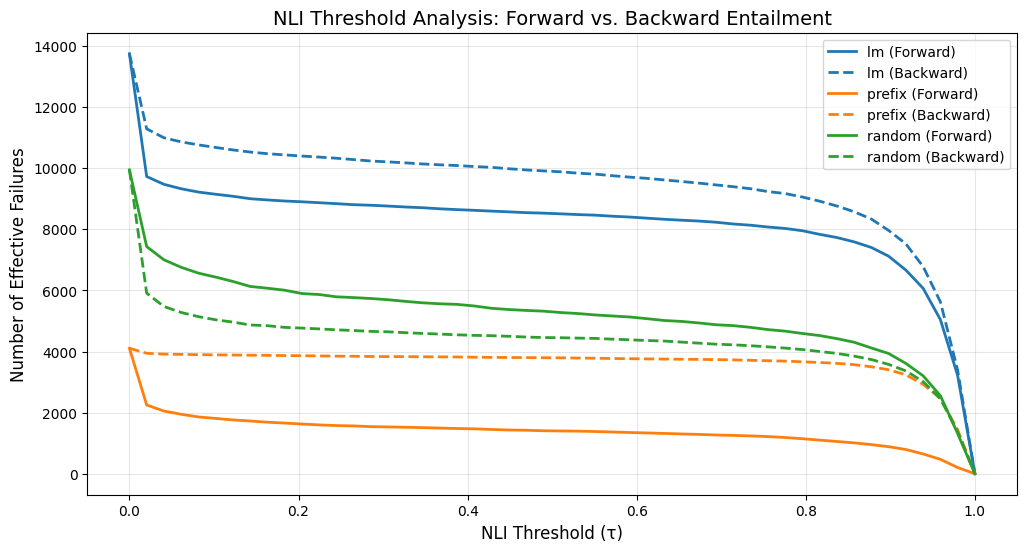

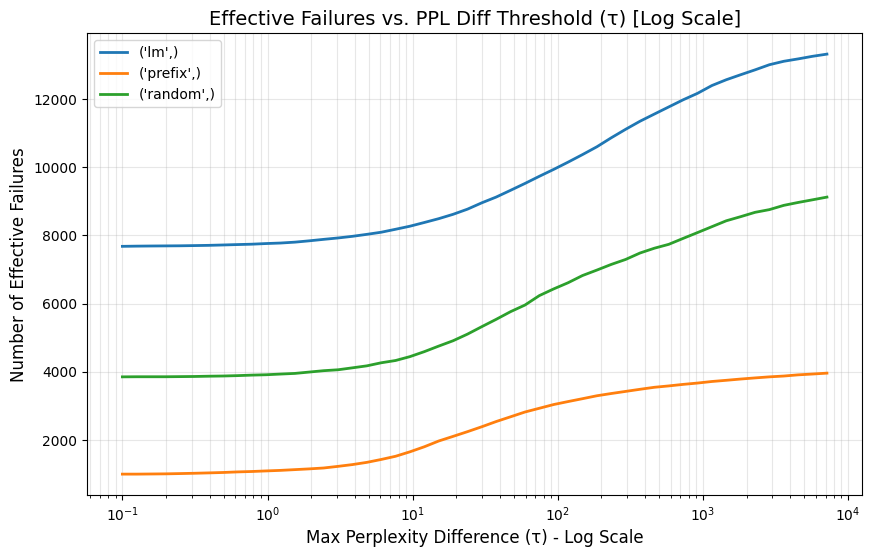

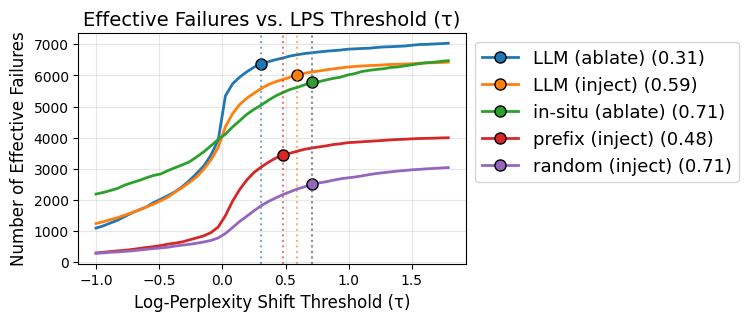

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('default')
import numpy as np
from kneed import KneeLocator
from matplotlib.lines import Line2D

df_flipped["nli_mean"] = (df_flipped["nli_forward"] + df_flipped["nli_backward"]) / 2
df_flipped["nli_min"] = np.minimum(df_flipped["nli_forward"], df_flipped["nli_backward"])

def plot_sweet_spot(df, metric_col, title, xlabel, groupby_cols=['explainer', 'strategy']):
    # Define thresholds to test
    thresholds = np.linspace(0, 1.0, 50)

    # Group by the specified columns
    groups = df.groupby(groupby_cols)

    plt.figure(figsize=(5, 3))
    legend_handles = []
    for name, group in groups:
        # Create label string based on group keys
        label = "-".join(name) if isinstance(name, tuple) else str(name)
        counts = []
        for tau in thresholds:
            # Effective failures: flipped AND passes the threshold
            if 'nli' in metric_col:
                # For NLI, higher is better (more entailment)
                mask = (group['nli_forward'] >= tau) & (group['nli_backward'] >= tau)
            else:
                # For PPL diff, lower is better (normalized example)
                mask = group['ppl_diff'] <= tau * group['ppl_diff'].max()

            counts.append(mask.sum())

        line = plt.plot(thresholds, counts, label=label, linewidth=2)
        curve_color = line[0].get_color()
        # ==========================================
        # find Sweet Spot (Knee / Elbow)
        # ==========================================
        direction = 'decreasing' if 'nli' in metric_col else 'increasing'

        # find Sweet Spot (Knee / Elbow) concave then convex
        kn = KneeLocator(thresholds, counts, curve='convex', direction=direction)
        if kn.knee is None:
            kn = KneeLocator(thresholds, counts, curve='concave', direction=direction)

        knee_x = kn.knee
        knee_y = kn.knee_y

        if knee_x is not None:
            plt.plot(knee_x, knee_y, marker='o', markersize=8, color=curve_color,
                     markeredgecolor='black', linestyle='None')

            # draw vertical line at the knee point
            plt.axvline(x=knee_x, color=curve_color, linestyle=':', alpha=0.6)

            # add threshold label (τ=0.xx)
            """plt.annotate(f'τ={knee_x:.2f}', xy=(knee_x, knee_y),
                         xytext=(10, 5), textcoords='offset points',
                         color=curve_color, fontsize=10, fontweight='bold')"""
            legend_handles.append(Line2D([0], [0], color=curve_color, lw=2,
                                         marker='o', markerfacecolor=curve_color,
                                         markeredgecolor='black', markersize=8,
                                         label=f"{label} ({knee_x:.2f})"))
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylim(0, 8000)
    plt.ylabel("Number of Effective Failures", fontsize=12)
    plt.legend(handles=legend_handles, bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=13)
    plt.grid(True, alpha=0.3)

    plt.savefig('BNLI_sweet_spot.pdf', bbox_inches='tight')
    plt.show()

# Plot 1: NLI Threshold Analysis - Bidirectional (Default)
plot_sweet_spot(
    df_flipped,
    'nli_scores',
    "Effective Failures vs. BNLI Threshold (τ)",
    "BNLI Threshold (τ)",
    groupby_cols=['strategy_label']
)

# Plot 1b: NLI Threshold Analysis - Forward and Backward separately
thresholds = np.linspace(0, 1.0, 50)
plt.figure(figsize=(12, 6))

for strategy, group in df_flipped.groupby('strategy'):
    fwd_counts = [(group['nli_forward'] >= tau).sum() for tau in thresholds]
    bwd_counts = [(group['nli_backward'] >= tau).sum() for tau in thresholds]

    line = plt.plot(thresholds, fwd_counts, label=f"{strategy} (Forward)", linewidth=2)
    plt.plot(thresholds, bwd_counts, label=f"{strategy} (Backward)",
             linewidth=2, linestyle='--', color=line[0].get_color())

plt.title("NLI Threshold Analysis: Forward vs. Backward Entailment", fontsize=14)
plt.xlabel("NLI Threshold (τ)", fontsize=12)
plt.ylabel("Number of Effective Failures", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: PPL Diff Threshold Analysis
ppl_max = df_flipped['ppl_diff'].quantile(0.95)
ppl_min = max(1e-1, df_flipped['ppl_diff'].quantile(0.05))
ppl_thresholds = np.logspace(np.log10(ppl_min), np.log10(ppl_max), 50)

plt.figure(figsize=(10, 6))
for (strategy), group in df_flipped.groupby(['strategy']):
    counts = [(group['ppl_diff'] <= tau).sum() for tau in ppl_thresholds]
    plt.plot(ppl_thresholds, counts, label=f"{strategy}", linewidth=2)

plt.xscale('log')
plt.title("Effective Failures vs. PPL Diff Threshold (τ) [Log Scale]", fontsize=14)
plt.xlabel("Max Perplexity Difference (τ) - Log Scale", fontsize=12)
plt.ylabel("Number of Effective Failures", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

# log diff
ppl_max = df_flipped['log_ppl_diff'].quantile(0.97)
ppl_min = max(-1, df_flipped['log_ppl_diff'].quantile(0.05)) #df_flipped['log_ppl_diff'].quantile(0.03)
ppl_thresholds = np.linspace(ppl_min, ppl_max, 50)
plt.figure(figsize=(5, 3))
legend_handles = []
for strategy, group in df_flipped.groupby(['strategy_label']):
    strat_name = strategy[0] if isinstance(strategy, tuple) else strategy

    counts = np.array([(group['log_ppl_diff'] <= tau).sum() for tau in ppl_thresholds])

    line = plt.plot(ppl_thresholds, counts, label=f"{strat_name}", linewidth=2)
    curve_color = line[0].get_color()

    # ==========================================
    # 2. Sweet Spot (Knee)
    # ==========================================
    # To ensure the knee detection is meaningful, we only attempt to find a knee if there are enough data points and some variation in counts.
    if len(counts) > 5 and counts.max() > counts.min():
        dy = np.gradient(counts, ppl_thresholds)
        max_slope_idx = np.argmax(dy)

        x_sub = ppl_thresholds[max_slope_idx:]
        y_sub = counts[max_slope_idx:]

        if len(x_sub) > 2:
            kn = KneeLocator(x_sub, y_sub, curve='concave', direction='increasing')
            knee_x = kn.knee
            knee_y = kn.knee_y
        else:
            knee_x, knee_y = None, None

        # If knee detection fails (e.g., due to insufficient data points or lack of a clear knee), we can apply a backup heuristic:
        if knee_x is None:
            target_val = counts.max() * 0.85
            backup_idx = np.argmax(counts >= target_val)
            knee_x = ppl_thresholds[backup_idx]
            knee_y = counts[backup_idx]

        # annotate the knee point on the curve
        if knee_x is not None:
            plt.plot(knee_x, knee_y, marker='o', markersize=8, color=curve_color,
                     markeredgecolor='black', linestyle='None')
            plt.axvline(x=knee_x, color=curve_color, linestyle=':', alpha=0.6)
            legend_handles.append(Line2D([0], [0], color=curve_color, lw=2,
                                     marker='o', markerfacecolor=curve_color,
                                     markeredgecolor='black', markersize=8,
                                     label=f"{strat_name} ({knee_x:.2f})"))
            """plt.annotate(f'τ={knee_x:.2f}', xy=(knee_x, knee_y),
                         xytext=(10, -15), textcoords='offset points',
                         color=curve_color, fontsize=10, fontweight='bold')"""
        else:
            legend_handles.append(Line2D([0], [0], color=curve_color, lw=2, label=strat_name))

# plt.xscale('log')
plt.title("Effective Failures vs. LPS Threshold (τ)", fontsize=14)
plt.xlabel("Log-Perplexity Shift Threshold (τ)", fontsize=12)
plt.ylabel("Number of Effective Failures", fontsize=12)
plt.legend(handles = legend_handles, bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=13)
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.savefig('LPS_sweet_spot.pdf', bbox_inches='tight')
plt.show()

##  2. Qualitative Analysis

In [10]:
# ... existing code ...
from collections import Counter
import spacy

# Load the small English spaCy model. This is already done and assumed available.
nlp_model = spacy.load("en_core_web_sm")

# Initialize an empty list to store detailed NLP analysis results for each "failure" word.
# This list will later be converted into a pandas DataFrame.
analyzed_failure_words = []

# Iterate over each "failure" item from the df_flipped DataFrame.
# The df_flipped DataFrame is assumed to be available from previous cells and contains
# columns like 'word', 'model', 'explainer', and 'item_id' for each failure case.
for index, row in df_flipped_filter.iterrows():
    word_to_analyze = str(row["word"]).strip()  # Extract the "failure" word and clean it
    model_name = row["model"]  # Get the model associated with this failure
    explainer_name = row["explainer"]  # Get the explainer method
    original_item_id = row["item_id"]  # Link back to the original item ID
    label = row["true_label"]
    if not word_to_analyze:
        continue  # Skip processing if the word is empty

    # Process the extracted word using the loaded spaCy NLP model.
    # spaCy will tokenize the text and assign linguistic annotations.
    doc = nlp_model(word_to_analyze)

    # A single "failure" word (e.g., a compound word or phrase treated as one entry in df_flipped_filter)
    # might be tokenized by spaCy into multiple tokens. We analyze each individual token.
    for token in doc:
        analyzed_failure_words.append({
            "token_text": token.text,  # The actual text of the spaCy token
            "pos": token.pos_,  # Coarse-grained Part-of-Speech tag (e.g., NOUN, VERB, ADJ)
            "tag": token.tag_,  # Fine-grained Part-of-Speech tag (e.g., NN for noun, VBD for past tense verb)
            "ent_type": token.ent_type_,  # Named Entity Type (e.g., PERSON, GPE for geopolitical entity)
            "is_stop": token.is_stop,  # Boolean flag: True if the token is a stop word
            "original_failure_word": word_to_analyze,  # The full "failure" word as it appeared in df_flipped_filter
            "original_item_id": original_item_id,  # The ID of the original data item
            "model": model_name,  # The machine learning model under analysis
            "explainer": explainer_name,  # The XAI method (explainer) that identified this failure
            "label": label,
            "text_a": row["text_a"],
            "text_b": row["text_b"],
            "edit_text_a": row["edit_text_a"],
            "edit_text_b": row["edit_text_b"],
            "task": row["task"],
        })

# Convert the list of dictionaries containing detailed NLP analysis results into a pandas DataFrame.
# This DataFrame will be the primary output of this cell, providing a structured way to analyze the data.
df_failure_nlp_analysis = pd.DataFrame(analyzed_failure_words)

# Define a directory and file name for saving the results.
# 'exp_dir' is assumed to be defined in a previous cell (e.g., '../experiments/').
# We create a new subdirectory 'nlp_analysis' within 'exp_dir' for these specific results.
output_analysis_dir = Path(exp_dir) / "nlp_analysis"
output_analysis_dir.mkdir(parents=True, exist_ok=True)  # Ensure the output directory structure exists

# Construct the full path for the output file.
output_file_path = output_analysis_dir / "failure_words_nlp_analysis.jsonl"

# Save the DataFrame to a JSONL file.
# 'orient="records"' ensures each row is saved as a JSON object.
# 'lines=True' writes each JSON object on a new line, creating a JSON Lines file.
# 'force_ascii=False' allows non-ASCII characters to be saved directly (e.g., for Chinese text if applicable).
df_failure_nlp_analysis.to_json(output_file_path, orient="records", lines=True, force_ascii=False)

print(f"Detailed NLP analysis of failure words saved to: {output_file_path}")

# Display the first few rows of the newly created DataFrame to quickly inspect its structure and content.
df_failure_nlp_analysis

Detailed NLP analysis of failure words saved to: ../experiments/nlp_analysis/failure_words_nlp_analysis.jsonl


,token_text,pos,tag,ent_type,is_stop,original_failure_word,original_item_id,model,explainer,label,text_a,text_b,edit_text_a,edit_text_b,task
0,cold,ADJ,JJ,,False,cold,sst2_49367,distilbert-base-uncased,occlusion,0,"cold , gray , antiseptic and",None,"cool, gray, antiseptic and",None,sst2
1,cold,ADJ,JJ,,False,cold,sst2_54542,distilbert-base-uncased,occlusion,0,"cold ,",None,cool,None,sst2
2,mess,NOUN,NN,,False,mess,sst2_10053,distilbert-base-uncased,occlusion,0,the mess that is world traveler,None,the chaotic person that is a world traveler,None,sst2
3,t,PROPN,NNP,,False,t,sst2_42812,distilbert-base-uncased,occlusion,1,"on the surface a silly comedy , scotland , pa ...",None,"on the surface a silly comedy, Scotland, PA wo...",None,sst2
4,wit,NOUN,NN,,False,wit,sst2_24242,distilbert-base-uncased,occlusion,1,white 's dry wit,None,white's dry humor,None,sst2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3037,levels,NOUN,NNS,,False,levels,news_33843,facebook/bart-large,occlusion,0,Stocks Close Lower Amid Rising Oil Prices,NEW YORK - A grim combination of higher oil pr...,Stocks Close Lower Amid Rising Oil Prices,NEW YORK - A grim combination of higher oil pr...,news
3038,(,PUNCT,-LRB-,,False,(AP,news_42295,facebook/bart-large,occlusion,2,Oil hits high on Nigeria threat,"LONDON, England -- Oil prices have surged to h...",(AP Oil hits high on Nigeria threat,"LONDON, England -- Oil prices have surged to h...",news
3039,AP,PROPN,NNP,ORG,False,(AP,news_42295,facebook/bart-large,occlusion,2,Oil hits high on Nigeria threat,"LONDON, England -- Oil prices have surged to h...",(AP Oil hits high on Nigeria threat,"LONDON, England -- Oil prices have surged to h...",news
3040,(,PUNCT,-LRB-,,False,(UNCTAD,news_109683,facebook/bart-large,occlusion,2,POITIER SAW #39;DEEP MISMATCH #39;,"Oscar-winning actor Sidney Poitier, who starre...",POITIER SAW #39;DEEP MISMATCH #39;,"Oscar‑winning actor Sidney Poitier, who starre...",news



### 1. Overall POS Tag Distribution
 the general distribution of coarse-grained POS tags across all analyzed failure words.



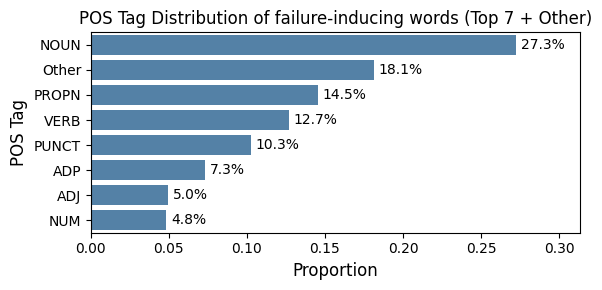

,category,count,ratio
0,NOUN,829,0.272518
1,Other,552,0.181460
2,PROPN,442,0.145299
3,VERB,386,0.126890
4,PUNCT,312,0.102564
5,ADP,223,0.073307
6,ADJ,151,0.049638
7,NUM,147,0.048323


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use('default')
top_n = 7
category_col = 'pos'

plot_df = df_failure_nlp_analysis.copy()
plot_df[category_col] = plot_df[category_col].fillna('').replace('', 'UNKNOWN')

top_categories = plot_df[category_col].value_counts().head(top_n).index
plot_df['plot_category'] = plot_df[category_col].where(
    plot_df[category_col].isin(top_categories),
    'Other'
)

summary = (
    plot_df['plot_category']
    .value_counts()
    .rename_axis('category')
    .reset_index(name='count')
)

summary['ratio'] = summary['count'] / summary['count'].sum()
order = summary.sort_values('ratio', ascending=False)['category']

plt.figure(figsize=(6, 3))
ax = sns.barplot(
    data=summary,
    y='category',
    x='ratio',
    order=order,
    color='steelblue'
)

ax.set_title('POS Tag Distribution of failure-inducing words (Top 7 + Other)')
ax.set_xlabel('Proportion', fontsize=12)
ax.set_ylabel('POS Tag', fontsize=12)
ax.set_xlim(0, summary['ratio'].max() * 1.15)

for i, (_, row) in enumerate(summary.set_index('category').loc[order].reset_index().iterrows()):
    ax.text(
        row['ratio'] + 0.003,
        i,
        f"{row['ratio']:.1%}",
        va='center'
    )

plt.tight_layout()
plt.savefig('POS_tag_distribution.pdf', bbox_inches='tight')
plt.show()

summary.sort_values('ratio', ascending=False)




### 2. POS Tag Distribution by Models



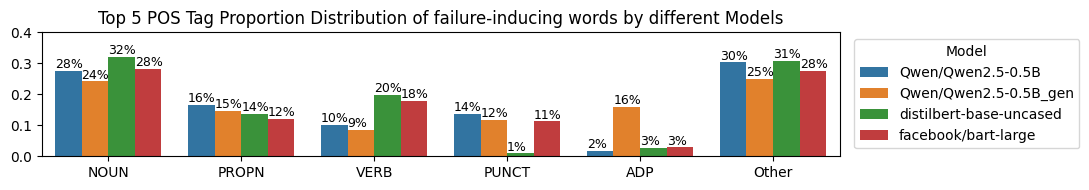

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.style.use('default')

# 1. Prepare data
top_n = 5
category_col = 'pos'
plot_df = df_failure_nlp_analysis.copy()
plot_df[category_col] = plot_df[category_col].fillna('UNKNOWN').replace('', 'UNKNOWN')

# 2. Identify top 5 categories overall
top_categories = plot_df[category_col].value_counts().head(top_n).index

# 3. Group remaining into 'Other'
plot_df['pos_grouped'] = plot_df[category_col].where(
    plot_df[category_col].isin(top_categories), 'Other'
)

# 4. Calculate proportions per model
# Group by model and the new grouped POS, then normalize within each model
summary = (
    plot_df.groupby(['model', 'pos_grouped'])
    .size()
    .rename('count')
    .reset_index()
)

# Calculate ratio per model
summary['proportion'] = summary.groupby('model')['count'].transform(lambda x: x / x.sum())

# 5. Define order (Top 5 sorted by frequency, then 'Other')
order = list(top_categories) + ['Other']

# 6. Plot
plt.figure(figsize=(11, 2))
ax = sns.barplot(
    data=summary,
    x='pos_grouped',
    y='proportion',
    hue='model',
    order=order
)

plt.title('Top 5 POS Tag Proportion Distribution of failure-inducing words by different Models')
plt.ylabel(None)
plt.ylim(0, 0.4)
plt.xlabel(None)
plt.legend(title='Model',
           bbox_to_anchor=(1.01, 1),
           loc='upper left',#'lower left',
           ncols=1)

# Add percentage labels
for p in ax.patches:
    hei = p.get_height()
    if hei > 0:
        ax.text(
            #width + 0.005,
            #p.get_y() + p.get_height() / 2,
            p.get_x() ,
            p.get_height() + 0.02,
            f'{hei:.0%}',
            va='center',
            fontsize=9,
        )

plt.tight_layout()
plt.savefig('POS_tag_distribution.pdf', bbox_inches='tight')
plt.show()




### 3. Top N Fine-Grained (TAG) Tags by Explainer

To get a more granular view, we can examine the fine-grained POS tags. Since there can be many, we'll focus on the top N tags.



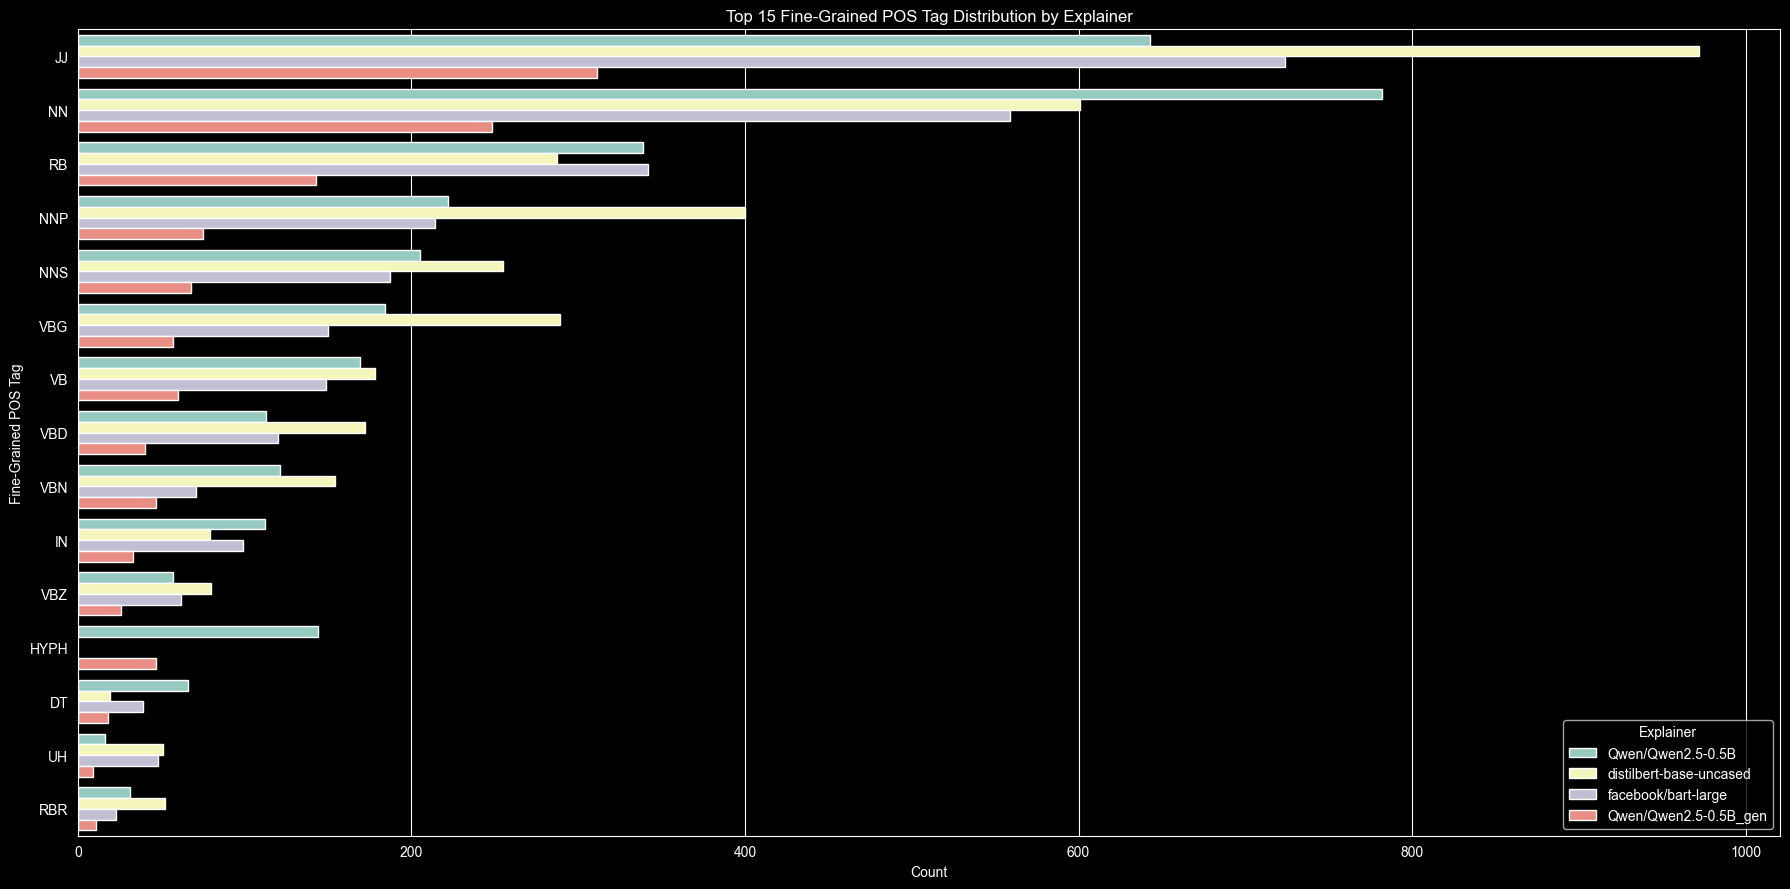

In [15]:
# Select top N tags for better readability
top_n_tags = df_failure_nlp_analysis['tag'].value_counts().head(15).index
df_top_tags = df_failure_nlp_analysis[df_failure_nlp_analysis['tag'].isin(top_n_tags)]

plt.figure(figsize=(18, 9))
sns.countplot(data=df_top_tags, y='tag', hue='model',
              order=top_n_tags)
plt.title('Top 15 Fine-Grained POS Tag Distribution by Explainer')
plt.xlabel('Count')
plt.ylabel('Fine-Grained POS Tag')
plt.legend(title='Explainer')
plt.tight_layout()
plt.show()



### 4. Named Entity Type (ENT_TYPE) Distribution by Explainer

This will show if certain explainers tend to highlight "failure" words that are specific types of entities (e.g., persons, locations, organizations).



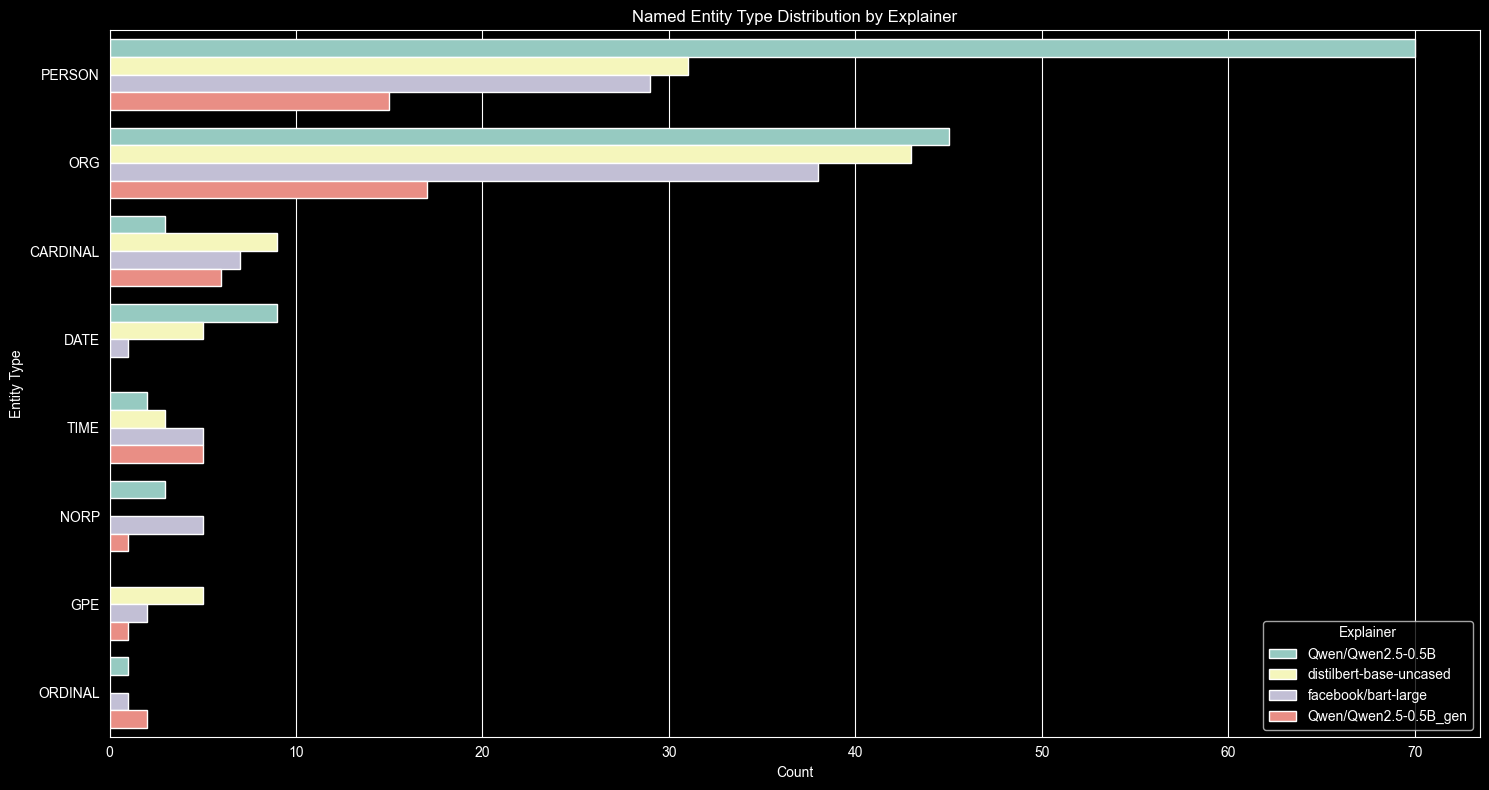

In [16]:
# Filter out tokens that are not part of any named entity
df_entities = df_failure_nlp_analysis[df_failure_nlp_analysis['ent_type'] != '']

if not df_entities.empty:
    plt.figure(figsize=(15, 8))
    sns.countplot(data=df_entities, y='ent_type', hue='model',
                  order=df_entities['ent_type'].value_counts().index)
    plt.title('Named Entity Type Distribution by Explainer')
    plt.xlabel('Count')
    plt.ylabel('Entity Type')
    plt.legend(title='Explainer')
    plt.tight_layout()
    plt.show()
else:
    print("No named entities found in failure words for this analysis.")

In [38]:
df_failure_nlp_analysis[['model']].drop_duplicates().values

array([['Qwen/Qwen2.5-0.5B'],
       ['facebook/bart-large'],
       ['distilbert-base-uncased'],
       ['Qwen/Qwen2.5-0.5B_gen']], dtype=object)

In [60]:
# ... existing code ...
df_failure_nlp_analysis.head()


def analyze_top_failures_by_category(df_nlp_analysis, category_type, top_category_labels=3, top_tokens_per_label=3,
                                     example_n=3, task="sst2"):
    """
    Analyzes and prints the most frequent tokens for a given linguistic category (POS, TAG, ENT_TYPE),
    along with example failure words and their original item IDs, grouped by explainer and model.

    This function iterates through each unique combination of explainer and model present in the
    'df_nlp_analysis' DataFrame. For each combination, it identifies the most frequent labels
    within the specified 'category_type' (e.g., 'NOUN' for 'pos', 'NNP' for 'tag', 'PERSON' for 'ent_type').
    Then, for each of these top labels, it finds the most frequent 'token_text' that fall under that label.
    Finally, it provides concrete examples of the 'original_failure_word' and 'original_item_id'
    where these highly frequent tokens appeared, offering a qualitative insight into the types of words
    that cause failures for different explainers and models.

    Args:
        df_nlp_analysis (pd.DataFrame): DataFrame containing NLP analysis of failure words
                                       (e.g., df_failure_nlp_analysis). Must include columns:
                                       'explainer', 'model', 'token_text', 'pos', 'tag', 'ent_type',
                                       'original_failure_word', 'original_item_id'.
        category_type (str): The linguistic category to analyze. Valid options are 'pos' (coarse-grained POS),
                             'tag' (fine-grained POS), or 'ent_type' (Named Entity Type).
        top_category_labels (int): The number of most frequent labels to consider within the specified
                                   'category_type' for each explainer/model combination. Defaults to 3.
        top_tokens_per_label (int): The number of most frequent tokens to display for each of the
                                    top category labels. Defaults to 3.
        example_n (int): The number of unique original failure word examples (identified by original_item_id)
                         to show for each top token. Defaults to 3.
    """
    df_nlp_analysis = df_nlp_analysis.copy()
    df_nlp_analysis = df_nlp_analysis[df_nlp_analysis['task'] == task]
    if category_type not in ['pos', 'tag', 'ent_type']:
        print(f"Error: Invalid category_type '{category_type}'. Must be 'pos', 'tag', or 'ent_type'.")
        return

    print(f"--- Qualitative Analysis for Top '{category_type}' and Tokens for task {task}---")
    print("-" * 80)

    # Iterate through unique explainer-model combinations to analyze failures for each
    for model in df_nlp_analysis['model'].drop_duplicates().values:
        print(f"\n Model: {model}")
        print("=" * (len(model) + 15))

        # Filter the DataFrame for the current explainer and model
        subset_df = df_nlp_analysis[
            #(df_nlp_analysis['explainer'] == explainer) &
            df_nlp_analysis['model'] == model
            ]

        # Special handling for 'ent_type' to exclude empty entity types
        if category_type == 'ent_type':
            subset_df = subset_df[subset_df['ent_type'] != '']
            if subset_df.empty:
                print(f"  No named entities found for /{model} to analyze.")
                continue

        # Get the most frequent labels within the specified category for the current subset
        top_labels = subset_df[category_type].value_counts().head(top_category_labels).index.tolist()

        if not top_labels:
            print(f"  No data available for category '{category_type}' for /{model} combination.")
            continue

        # Iterate through each of the top labels
        for label in top_labels:
            print(f"\n  Category '{category_type}' = '{label}'")
            print(f"  {'-' * (len(category_type) + len(label) + 10)}")

            # Filter for the current label and get the most frequent tokens within it
            label_df = subset_df[subset_df[category_type] == label]
            top_tokens = label_df['token_text'].value_counts().head(top_tokens_per_label).index.tolist()

            if not top_tokens:
                print(f"    No tokens found for category label '{label}'.")
                continue

            # For each top token, print its count and example occurrences
            for token in top_tokens:
                token_count = label_df['token_text'].value_counts()[token]
                print(f"    Token: '{token}' (Count: {token_count})")

                # Retrieve distinct examples (original failure word and item ID)
                # Ensure examples are unique by original_item_id to represent different failure instances
                examples_df = label_df[label_df['token_text'] == token][
                    ['original_failure_word', 'original_item_id', "label", "text_a", "edit_text_a","text_b", "edit_text_b" ]
                ].drop_duplicates(subset=['original_item_id']).head(example_n)

                if not examples_df.empty:
                    print("      Examples (Original Failure Word, Item ID):")
                    for _, example_row in examples_df.iterrows():
                        print(
                            f"        - '{example_row['original_failure_word']}' (ID: {example_row['original_item_id']}) Label: {example_row['label']} \nText:      {example_row['text_a']} || {example_row['text_b']} \nEdit Text: {example_row['edit_text_a']} || {example_row['edit_text_b']}")

                else:
                    print("      No specific examples found.")

    print("\n--- Qualitative Analysis Complete ---")


# --- Examples of using the qualitative analysis function ---




In [63]:
# 1. Analyze top POS tags and their most frequent tokens
print("\n" + "#" * 90)
print("### Analyzing Top Coarse-Grained POS Tags (e.g., NOUN, VERB) ###")
print("#" * 90)
analyze_top_failures_by_category(df_failure_nlp_analysis, 'pos', top_category_labels=1 ,top_tokens_per_label=3,
                                 example_n=3, task="github")




##########################################################################################
### Analyzing Top Coarse-Grained POS Tags (e.g., NOUN, VERB) ###
##########################################################################################
--- Qualitative Analysis for Top 'pos' and Tokens for task github---
--------------------------------------------------------------------------------

 Model: facebook/bart-large

  Category 'pos' = 'NOUN'
  -----------------
    Token: 'bug' (Count: 6)
      Examples (Original Failure Word, Item ID):
        - 'bug' (ID: github_179480) Label: 0 
Text:      bug: dataverse_handoff_view.py || error checking is lost. siteUrl can be blank and is not checked for validty 
Edit Text: dataverse_handoff_view.py || error checking is lost. siteUrl can be blank and is not checked for validty
        - 'bug' (ID: github_317513) Label: 0 
Text:      RuntimeError: source object number out of range || ## Describe the bug (mandatory)
When trying to combine tw

In [65]:
# 2. Analyze top fine-grained POS tags (e.g., NNP, VBD)
print("\n" + "#" * 90)
print("### Analyzing Top Fine-Grained POS Tags (e.g., NNP, VBD) ###")
print("#" * 90)
analyze_top_failures_by_category(df_failure_nlp_analysis, 'tag', top_category_labels=1, top_tokens_per_label=3,
                                 example_n=3)




##########################################################################################
### Analyzing Top Fine-Grained POS Tags (e.g., NNP, VBD) ###
##########################################################################################
--- Qualitative Analysis for Top 'tag' and Tokens for task sst2---
--------------------------------------------------------------------------------

 Model: distilbert-base-uncased

  Category 'tag' = 'NN'
  ---------------
    Token: 'mess' (Count: 1)
      Examples (Original Failure Word, Item ID):
        - 'mess' (ID: sst2_10053) Label: 0 
Text:      the mess that is world traveler  || None 
Edit Text: the chaotic person that is a world traveler || None
    Token: 'wit' (Count: 1)
      Examples (Original Failure Word, Item ID):
        - 'wit' (ID: sst2_24242) Label: 1 
Text:      white 's dry wit  || None 
Edit Text: white's dry humor || None
    Token: 'problem' (Count: 1)
      Examples (Original Failure Word, Item ID):
        - 'problem

In [69]:
# 3. Analyze top Named Entity Types (e.g., PERSON, GPE)
print("\n" + "#" * 90)
print("### Analyzing Top Named Entity Types (ENT_TYPE) ###")
print("#" * 90)
analyze_top_failures_by_category(df_failure_nlp_analysis, 'ent_type', top_category_labels=1, top_tokens_per_label=3,
                                 example_n=3, task="github")


##########################################################################################
### Analyzing Top Named Entity Types (ENT_TYPE) ###
##########################################################################################
--- Qualitative Analysis for Top 'ent_type' and Tokens for task github---
--------------------------------------------------------------------------------

 Model: facebook/bart-large

  Category 'ent_type' = 'ORG'
  ---------------------
    Token: 'API' (Count: 2)
      Examples (Original Failure Word, Item ID):
        - 'API' (ID: github_184173) Label: 0 
Text:      `DimensionX` functions should use `element.offsetX` instead of CSS value || ## Explanation
Currently, the `DimensionWidth` and `DimensionHeight` WebElement functions use the `element.style.height` and `element.style.width`. 

However, the actual width of an element can differ from the height and width defined in the CSS, depending on the element's `display`, `min-width`, `max-width`, `over